## Plantilla corta para presentaciones en notebooks

Siga este orden al documentar cada experimento:

1. Objetivo del experimento (Markdown)
2. Setup: imports, semilla, carga de datos (Code)
3. Preprocesado y split (Code)
4. Experimento: modelo, hiperparámetros, CV (Code)
5. Métricas impresas: `accuracy`, `classification_report`, `confusion_matrix` (Code)
6. Visualizaciones (Code)
7. Resultados numéricos copiados y pegados (Markdown)
8. Conclusión y recomendaciones (Markdown)

Pegue el snippet de evaluación (código) en una celda de código y ejecute para obtener métricas y matriz de confusión visibles.


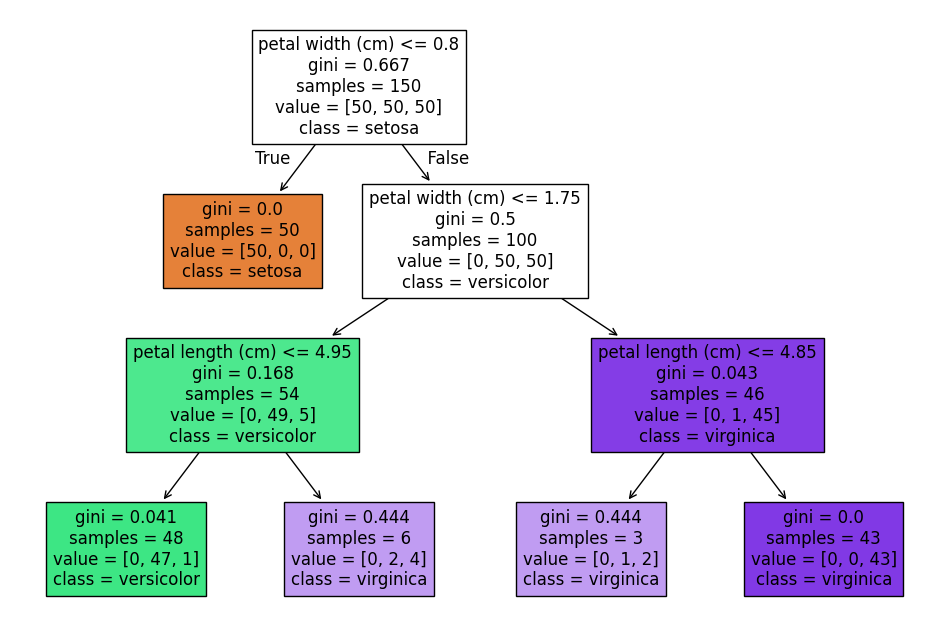

In [26]:
# Importa DecisionTreeClassifier para crear el modelo de árbol de decisión y plot_tree para visualizarlo
from sklearn.tree import DecisionTreeClassifier, plot_tree 
from sklearn.datasets import load_iris # Importa la función para cargar el dataset Iris
import matplotlib.pyplot as plt # Importa matplotlib para la visualización de gráficos

# Cargar el dataset Iris
iris = load_iris() 

# Separa las características (X) y las etiquetas (y) del dataset
# X contiene las características (longitud y ancho de sépalo y pétalo) e 
# y contiene las etiquetas de clase (0, 1, 2 para las tres especies de iris)
X, y = iris.data, iris.target 

# Entrenar árbol de decisión con criterio Gini y profundidad máxima de 3
# y una semilla aleatoria para reproducibilidad
clf = DecisionTreeClassifier(criterion="gini", max_depth=3, random_state=0) 
# Entrena el modelo de árbol de decisión con los datos de entrada X y las etiquetas y
clf.fit(X, y)

# Visualizar el árbol entrenado
# Crea una nueva figura para el gráfico con un tamaño específico
plt.figure(figsize=(12,8)) 
# Dibuja el árbol de decisión
# Rellena los nodos con colores, usa los nombres de las características y los nombres de las clases
plot_tree(clf, filled=True, feature_names=iris.feature_names, 
class_names=iris.target_names) 
# Muestra el gráfico del árbol de decisión
plt.show() 


## Preguntas de interpretación y análisis de errores

- Explique con sus propias palabras qué significan los falsos positivos (FP) y falsos negativos (FN) en un contexto médico (por ejemplo, diagnóstico de enfermedad cardíaca).
- Indique qué métrica sería más relevante en ese escenario (precisión o recall) y justifique su respuesta.

(Escriba sus respuestas debajo de cada pregunta o en una celda nueva llamada "Respuestas")

# Comparacion de profundidad en Arbol de Decision (Iris)
**Lasso** utiliza una penalización basada en la norma $L_1$ (el valor absoluto de los coeficientes). Debido a la geometría de esta restricción (que forma esquinas en los ejes del espacio de parámetros), el proceso de optimización tiende a forzar que los coeficientes de las variables menos importantes o redundantes sean **exactamente iguales a cero ($\beta_i = 0$)**. Al anular por completo el peso de una característica, Lasso la expulsa del modelo, actuando de forma automática como un selector de variables (*Feature Selection*).

- Modelo A: `max_depth = 1`
- Modelo B: `max_depth = profundidad recomendada` (elegida con validacion cruzada)

## Pregunta guia

¿Cual de los dos modelos se ajusta mejor a los datos?

## Criterio de seleccion

- Se prueba `max_depth` de 1 a 8 con validacion cruzada estratificada.
- Se elige la profundidad con mejor promedio de accuracy en validacion.
- Luego se compara ese modelo contra `max_depth=1` en un conjunto de prueba.

> Nota: Tener una profundidad mayor que el numero de clases **no garantiza** mejor rendimiento. En Iris hay 3 clases, pero la profundidad controla la complejidad de reglas de separacion, no el numero de clases directamente. Si es muy alta, puede sobreajustar.

Profundidad recomendada por CV: max_depth=3
Accuracy CV promedio (mejor): 0.9600

=== Resultados en conjunto de prueba ===
max_depth=1 -> accuracy: 0.6667
max_depth=3 -> accuracy: 0.9778

Reporte de clasificacion (max_depth=1):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.50      1.00      0.67        15
   virginica       0.00      0.00      0.00        15

    accuracy                           0.67        45
   macro avg       0.50      0.67      0.56        45
weighted avg       0.50      0.67      0.56        45

Reporte de clasificacion (max_depth=3):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      0.93      0.97        15
   virginica       0.94      1.00      0.97        15

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98  

e:\Unach\Semestre4\EstudioGITClaude\UNACH-4toSemestre\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\Unach\Semestre4\EstudioGITClaude\UNACH-4toSemestre\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\Unach\Semestre4\EstudioGITClaude\UNACH-4toSemestre\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


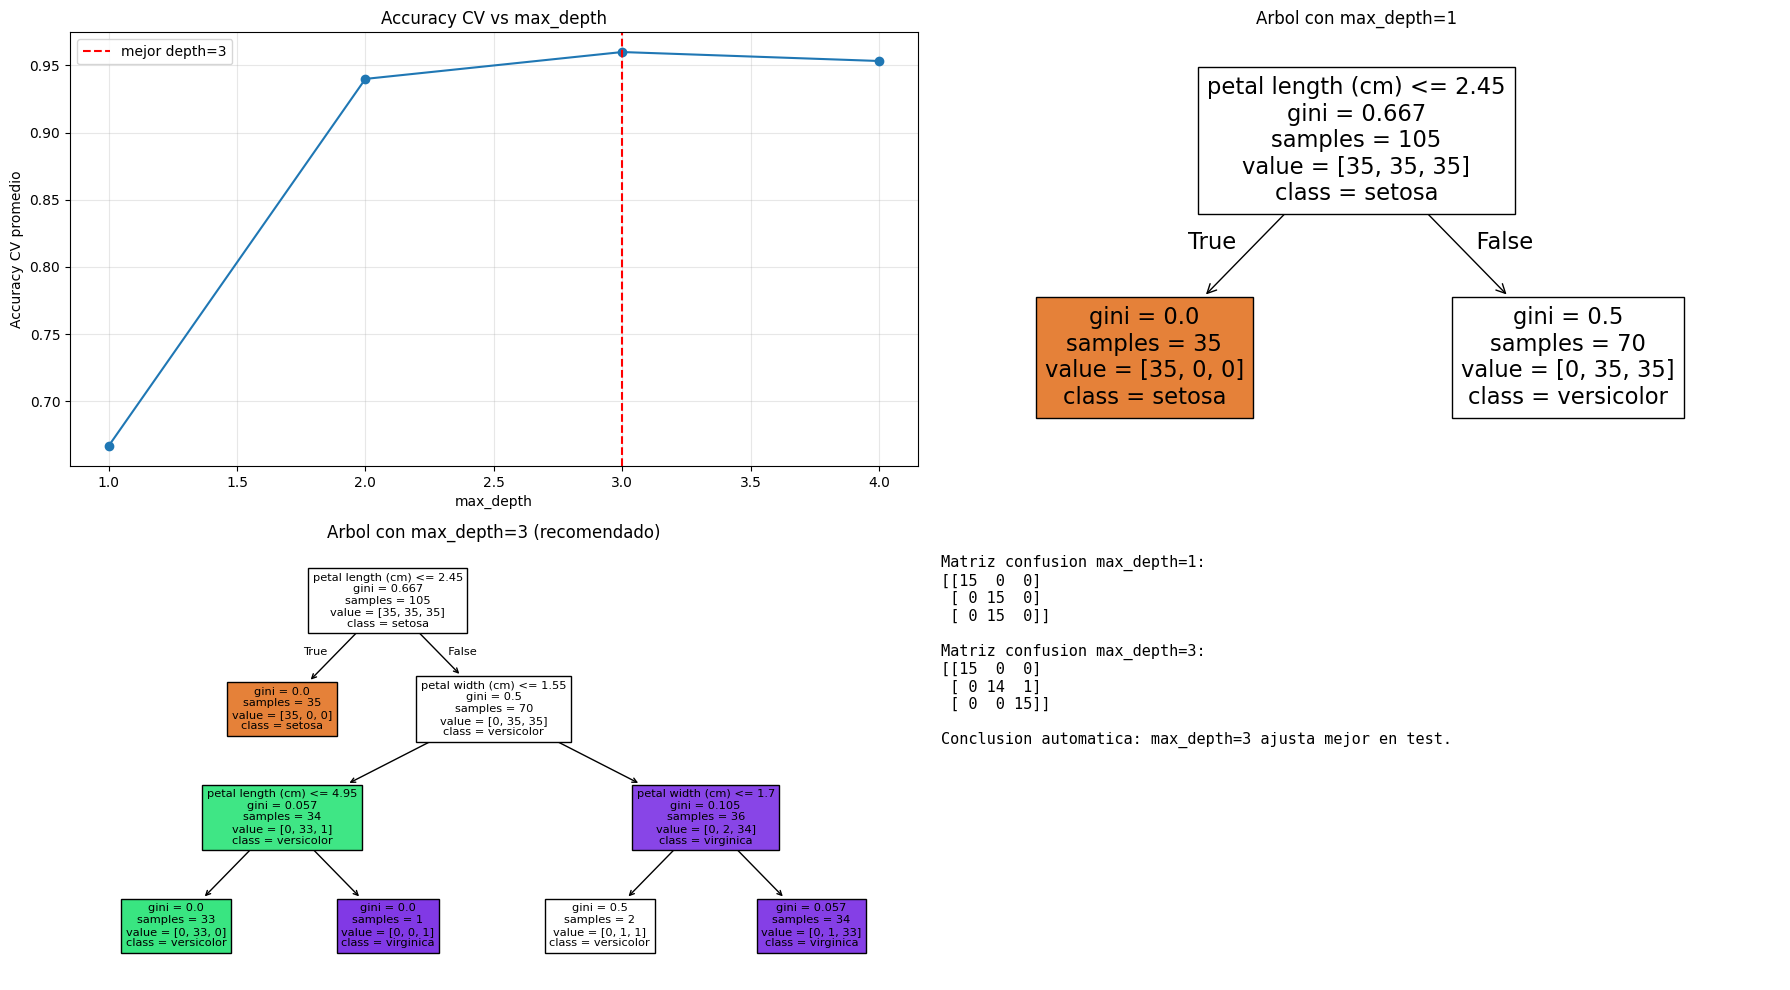


Respuesta: el modelo con max_depth=3 se ajusta mejor a los datos de prueba.


In [17]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# 1) Cargar datos
iris = load_iris()
X, y = iris.data, iris.target

# 2) Buscar profundidad recomendada por validacion cruzada
depths = range(1, 5)
#stratifiedkfold los parameros son n_splits=5, shuffle=True, random_state=42
# para asegurar que cada fold tenga una representacion similar de cada clase 
# y que los resultados sean reproducibles.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_means = []

# d es una variable que representa cada 
# valor de max_depth que queremos evaluar en el modelo de Decision Tree.
for d in depths:
  # random_state=42 se coloca el valor de 42 porque es un 
  # valor comúnmente utilizado para asegurar la reproducibilidad 
  # de los resultados en experimentos de machine learning. 
  # Al fijar el random_state, garantizamos que cada vez que 
  # se ejecute el código, se obtendrán los mismos resultados, 
  # lo cual es especialmente importante al comparar modelos o realizar validación cruzada.  
    model = DecisionTreeClassifier(criterion="gini", max_depth=d, random_state=42)
    # cross_val_score se utiliza para evaluar el rendimiento del modelo 
    # utilizando validación cruzada.
    scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")
    cv_means.append(scores.mean())

best_depth = depths[int(np.argmax(cv_means))]
print(f"Profundidad recomendada por CV: max_depth={best_depth}")
print(f"Accuracy CV promedio (mejor): {max(cv_means):.4f}")

# 3) Comparar max_depth=1 vs max_depth recomendado en hold-out
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

model_depth1 = DecisionTreeClassifier(criterion="gini", max_depth=1, random_state=42)
model_best = DecisionTreeClassifier(criterion="gini", max_depth=best_depth, random_state=42)

model_depth1.fit(X_train, y_train)
model_best.fit(X_train, y_train)

pred1 = model_depth1.predict(X_test)
predb = model_best.predict(X_test)

acc1 = accuracy_score(y_test, pred1)
accb = accuracy_score(y_test, predb)

print("\n=== Resultados en conjunto de prueba ===")
print(f"max_depth=1 -> accuracy: {acc1:.4f}")
print(f"max_depth={best_depth} -> accuracy: {accb:.4f}")

print("\nReporte de clasificacion (max_depth=1):")
print(classification_report(y_test, pred1, target_names=iris.target_names))
print(f"Reporte de clasificacion (max_depth={best_depth}):")
print(classification_report(y_test, predb, target_names=iris.target_names))

# 4) Visualizaciones
fig = plt.figure(figsize=(18, 10))

# (a) Curva de validacion por profundidad
ax1 = fig.add_subplot(2, 2, 1)
ax1.plot(list(depths), cv_means, marker="o")
ax1.axvline(best_depth, linestyle="--", color="red", label=f"mejor depth={best_depth}")
ax1.set_title("Accuracy CV vs max_depth")
ax1.set_xlabel("max_depth")
ax1.set_ylabel("Accuracy CV promedio")
ax1.legend()
ax1.grid(alpha=0.3)

# (b) Arbol max_depth=1
ax2 = fig.add_subplot(2, 2, 2)
plot_tree(
    model_depth1,
    filled=True,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    ax=ax2,
)
ax2.set_title("Arbol con max_depth=1")

# (c) Arbol max_depth recomendado
ax3 = fig.add_subplot(2, 2, 3)
plot_tree(
    model_best,
    filled=True,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    ax=ax3,
)
ax3.set_title(f"Arbol con max_depth={best_depth} (recomendado)")

# (d) Matriz de confusion comparativa (texto simple)
ax4 = fig.add_subplot(2, 2, 4)
ax4.axis("off")
cm1 = confusion_matrix(y_test, pred1)
cmb = confusion_matrix(y_test, predb)
text = (
    f"Matriz confusion max_depth=1:\n{cm1}\n\n"
    f"Matriz confusion max_depth={best_depth}:\n{cmb}\n\n"
    f"Conclusion automatica: {'max_depth=1' if acc1 > accb else f'max_depth={best_depth}'} ajusta mejor en test."
)
ax4.text(0.01, 0.98, text, va="top", ha="left", fontsize=11, family="monospace")

plt.tight_layout()
plt.show()

# 5) Mensaje final corto
if acc1 > accb:
    print("\nRespuesta: el modelo con max_depth=1 se ajusta mejor a los datos de prueba.")
elif accb > acc1:
    print(f"\nRespuesta: el modelo con max_depth={best_depth} se ajusta mejor a los datos de prueba.")
else:
    print("\nRespuesta: ambos modelos empatan en accuracy de prueba; se prefiere el mas simple (max_depth=1).")

## Interpretacion y respuesta

### Resultado observado

- Profundidad recomendada por validacion cruzada: `max_depth=3`
- Accuracy en prueba con `max_depth=1`: **0.6667**
- Accuracy en prueba con `max_depth=3`: **0.9778**

### ¿Cual modelo se ajusta mejor?

El modelo con **`max_depth=3`** se ajusta mejor a los datos para este ejercicio.

### ¿Por que?

1. Con `max_depth=1` el arbol es demasiado simple y solo separa bien una clase (setosa), pero confunde fuertemente versicolor y virginica (subajuste).
2. Con `max_depth=3` el arbol agrega reglas suficientes para separar mejor las tres clases, sin crecer innecesariamente.
3. Aumentar profundidad por encima de 3 no mejora el rendimiento promedio en validacion cruzada (la curva se estanca), por lo que profundidades mayores solo agregan complejidad sin beneficio claro.

### Conclusion practica

Para Iris, una profundidad intermedia (`max_depth=3`) logra mejor equilibrio entre:

- capacidad de representar patrones,
- generalizacion en datos no vistos,
- y simplicidad del modelo.

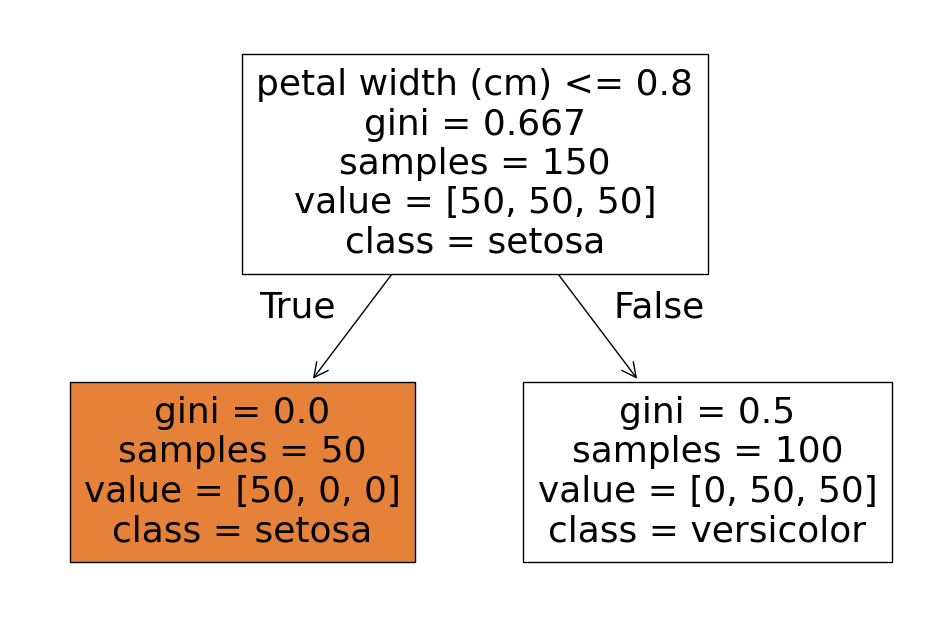

In [6]:
# Importa DecisionTreeClassifier para crear el modelo de árbol de decisión y 
# plot_tree para visualizarlo
from sklearn.tree import DecisionTreeClassifier, plot_tree 
from sklearn.datasets import load_iris # Importa la función para cargar el dataset Iris
import matplotlib.pyplot as plt # Importa matplotlib para la visualización de gráficos

# Cargar el dataset Iris
iris = load_iris() 

# Separa las características (X) y las etiquetas (y) del dataset
# X contiene las características (longitud y ancho de sépalo y pétalo) e 
# y contiene las etiquetas de clase (0, 1, 2 para las tres especies de iris)
X, y = iris.data, iris.target 

# Entrenar árbol de decisión con criterio Gini y profundidad máxima de 3
# y una semilla aleatoria para reproducibilidad
clf = DecisionTreeClassifier(criterion="gini", max_depth=1, random_state=0) 
clf1 = DecisionTreeClassifier(criterion="gini", max_depth=3, random_state=0)
clf2 = DecisionTreeClassifier(criterion="gini", max_depth=5, random_state=0)
# Entrena el modelo de árbol de decisión con los datos de entrada X y las etiquetas y
clf.fit(X, y)
clf1.fit(X, y)
clf2.fit(X, y)

# Visualizar el árbol entrenado
# Crea una nueva figura para el gráfico con un tamaño específico
plt.figure(figsize=(12,8)) 
# Dibuja el árbol de decisión
# Rellena los nodos con colores, usa los nombres de las características y los nombres de las clases
plot_tree(clf, filled=True, feature_names=iris.feature_names, 
class_names=iris.target_names) 
# Muestra el gráfico del árbol de decisión
plt.show() 


              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        50
  versicolor       0.98      0.96      0.97        50
   virginica       0.96      0.98      0.97        50

    accuracy                           0.98       150
   macro avg       0.98      0.98      0.98       150
weighted avg       0.98      0.98      0.98       150



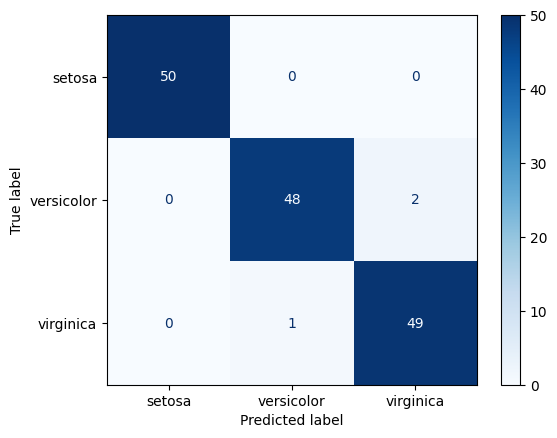

In [19]:
# libreria sklearn.metrics para evaluar el rendimiento del modelo de clasificación,
# incluyendo la matriz de confusión y el reporte de clasificación.
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay 
 
# Predicciones del modelo 
# y_pred es una variable que almacena las predicciones del modelo de árbol de decisión (clf)
# al aplicar el método predict sobre los datos de entrada X.
y_pred = clf.predict(X) 

# Matriz de confusión  
cm = confusion_matrix(y, y_pred) 
ConfusionMatrixDisplay(cm, 
display_labels=iris.target_names).plot(cmap="Blues") 

 # Reporte de métricas 
print(classification_report(y, y_pred, target_names=iris.target_names)) 
